In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val   = x_train_full[40000:].astype('float32')
y_val   = y_train_full[40000:]
x_test  = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# List GPU devices
print(tf.config.list_physical_devices('GPU'))

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)


Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.19.0


 ## Helper Function

In [2]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    """Train a model and return history + evaluation metrics."""
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(
        x_tr, to_categorical(y_tr, 10),
        validation_data=(x_v, to_categorical(y_v, 10)),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=0
    )
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed


def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    """Plot a given metric for multiple training histories on one graph."""
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

---
# Task 1: Data Preprocessing Experiments
## Task 1A  Normalization Comparison

In [3]:
# Preprocessing: building three versions of the data

#Exp A: No normalization (raw pixel values 0–255)
x_train_raw = x_train.copy()
x_val_raw   = x_val.copy()
x_test_raw  = x_test.copy()

#Exp B: Min-Max normalization -> [0, 1]
x_train_minmax = x_train / 255.0
x_val_minmax   = x_val   / 255.0
x_test_minmax  = x_test  / 255.0

#Exp C: Standardization per channel
channel_mean = x_train.mean(axis=(0, 1, 2))   # shape (3,)
channel_std  = x_train.std(axis=(0, 1, 2))    # shape (3,)
print(f"Channel mean: {channel_mean}")
print(f"Channel std : {channel_std}")

x_train_std = (x_train - channel_mean) / channel_std
x_val_std   = (x_val   - channel_mean) / channel_std
x_test_std  = (x_test  - channel_mean) / channel_std

print("Preprocessing complete.")

Channel mean: [125.32014  122.925385 113.78766 ]
Channel std : [63.027916 62.145065 66.73145 ]
Preprocessing complete.


In [ ]:
#BaselineCNN builder
#Defined as a function so we can instantiate a fresh model for each experiment.
def build_baseline_cnn(input_shape=(32, 32, 3)):
    """BaselineCNN: 2 conv blocks → Flatten → Dense(128) → Dense(10)."""
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name='BaselineCNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

build_baseline_cnn().summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
generator didn't yield

for label, x_tr, x_v, x_te in norm_experiments:
    print(f"\n=== {label} ===")
    model = build_baseline_cnn()
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_tr, y_train, x_v, y_val, x_te, y_test, epochs=20
    )
    norm_histories.append(history)
    norm_results[label] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc':   history.history['val_accuracy'][-1],
        'test_acc':  test_acc,
        'loss_ep1':  history.history['loss'][0],
    }


=== No Norm (0–255) ===


ValueError: 'D0_(rate=0.00)_D0_(rate=0.00)_BaselineCNN_conv2d_80_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

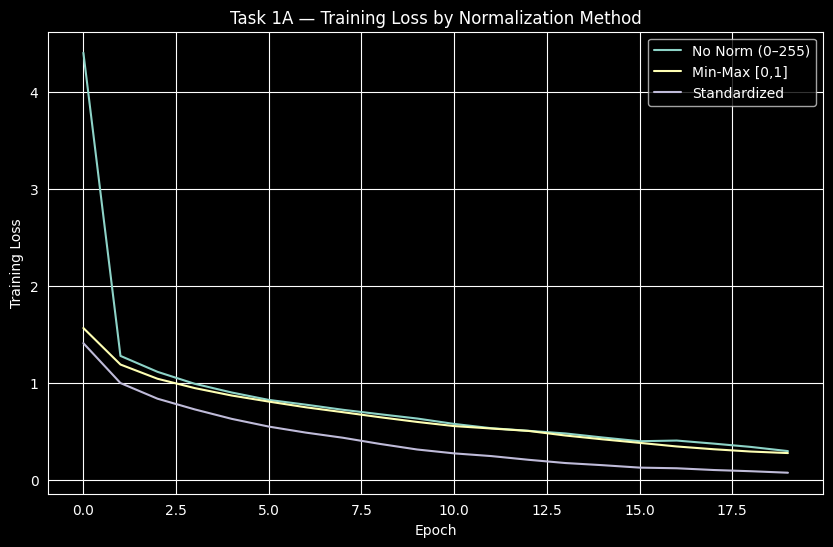

In [ ]:
# Plot: Training Loss curves (all 3 on one graph)
plot_curves(
    norm_histories,
    [e[0] for e in norm_experiments],
    metric='loss',
    title='Task 1A — Training Loss by Normalization Method',generator didn't yield
    ylabel='Training Loss'
)

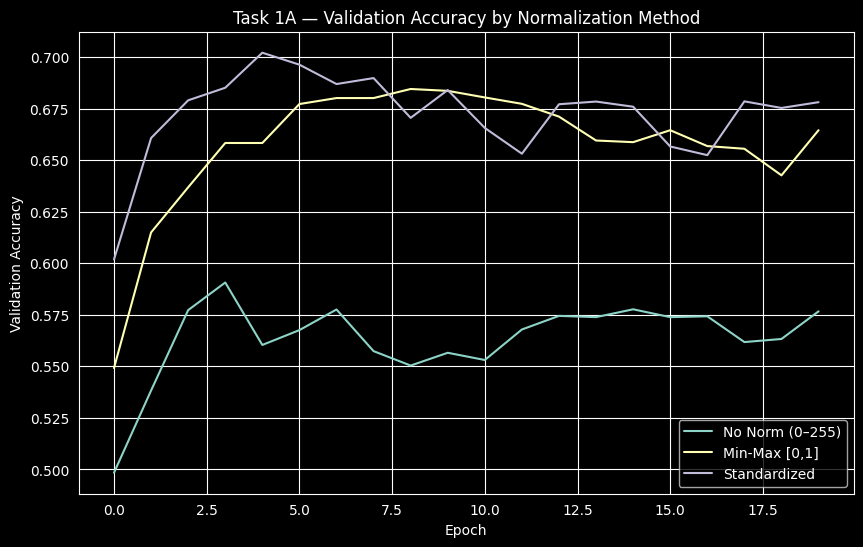

In [ ]:
#Plot: Validation Accuracy curves (all 3 on one graph)
plot_curves(
    norm_histories,
    [e[0] for e in norm_experiments],
    metric='val_accuracy',
    title='Task 1A — Validation Accuracy by Normalization Method',
    ylabel='Validation Accuracy'
)

In [ ]:
#Results Table (Task 1A)
print(f"{'Preprocessing':<22} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10} {'Loss@Ep1':>10}")
print('-' * 65)
for label, res in norm_results.items():
    print(f"{label:<22} {res['train_acc']:>10.4f} {res['val_acc']:>10.4f} "
          f"{res['test_acc']:>10.4f} {res['loss_ep1']:>10.4f}")

Preprocessing           Train Acc    Val Acc   Test Acc   Loss@Ep1
-----------------------------------------------------------------
No Norm (0–255)            0.8961     0.5767     0.5659     4.4016
Min-Max [0,1]              0.9025     0.6646     0.6576     1.5660
Standardized               0.9742     0.6782     0.6703     1.4101


---
## Task 1B - Data Augmentation Comparison

In [ ]:
#Train baseline WITHOUT augmentation (standardized data, 40 epochs)x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized
 = tf.image.resize(x_val_standardized,
 (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_standardized, (48, 48)).numpy()
print("=== No Augmentation ===")
model_no_aug = build_baseline_cnn()
hist_no_aug, _, _, _ = train_and_evaluate(
    model_no_aug,
    x_train_std, y_train,
    x_val_std,   y_val,
    x_test_std,  y_test,
    epochs=40
)

=== No Augmentation ===
Test Acc: 0.6793 | Test Loss: 3.0829 | Time: 575.4s


In [ ]:
#Configure ImageDataGenerator for augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1generator didn't yield
)
#Fit on training data to compute any internal statistics
datagen.fit(x_train_std)

#Train WITH augmentation using flow()
print("\n=== With Augmentation ===")
model_aug = build_baseline_cnn()

aug_gen   = datagen.flow(x_train_std, to_categorical(y_train, 10), batch_size=128)
val_data  = (x_val_std, to_categorical(y_val, 10))

start = time.time()
hist_aug = model_aug.fit(
    aug_gen,
    steps_per_epoch=len(x_train_std) // 128,
    validation_data=val_data,
    epochs=40,
    verbose=0
)
elapsed_aug = time.time() - start
aug_test_loss, aug_test_acc = model_aug.evaluate(
    x_test_std, to_categorical(y_test, 10), verbose=0
)
print(f"Test Acc: {aug_test_acc:.4f} | Test Loss: {aug_test_loss:.4f} | Time: {elapsed_aug:.1f}s")


=== With Augmentation ===


ValueError: 'D0_(rate=0.00)_D0_(rate=0.00)_BaselineCNN_conv2d_72_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

In [ ]:
#Plot: 4 curves - train/val for both conditions on one graph
plt.figure(figsize=(10, 6))
plt.plot(hist_no_aug.history['accuracy'],     label='Train Acc (No Aug)',   linestyle='--')
plt.plot(hist_no_aug.history['val_accuracy'], label='Val Acc (No Aug)',     linestyle='-')
plt.plot(hist_aug.history['accuracy'],        label='Train Acc (With Aug)', linestyle='--')
plt.plot(hist_aug.history['val_accuracy'],    label='Val Acc (With Aug)',   linestyle='-')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Task 1B — Augmentation Comparison (40 epochs)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Overfitting gap at epoch 40
gap_no_aug = hist_no_aug.history['accuracy'][-1] - hist_no_aug.history['val_accuracy'][-1]
gap_aug    = hist_aug.history['accuracy'][-1]    - hist_aug.history['val_accuracy'][-1]

print(f"No Augmentation  — Train: {hist_no_aug.history['accuracy'][-1]:.4f} "
      f"Val: {hist_no_aug.history['val_accuracy'][-1]:.4f}  Gap: {gap_no_aug:.4f}")
print(f"With Augmentation — Train: {hist_aug.history['accuracy'][-1]:.4f} "
      f"Val: {hist_aug.history['val_accuracy'][-1]:.4f}  Gap: {gap_aug:.4f}")
print()
if gap_aug < gap_no_aug:
    print("→ Augmentation overfits LESS (smaller gap)." )
else:
    print("→ No augmentation produced a smaller gap in this run.")

---

# Task 2A - Filter Count Comparison

In [ ]:

def build_filter_model(f1, f2, f3, f4, name='FilterModel'):
    """Two conv blocks (2 conv layers each) with configurable filter counts."""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        # Block 1
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # Block 2
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


filter_configs = {
    'Small':  (8,  8,  16,  16),
    'Medium': (32, 32, 64,  64),
    'Large':  (64, 64, 128, 128),
}

In [ ]:
#Print model summaries for each filter configuration
for name, filters in filter_configs.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}  Filters: {filters}")
    build_filter_model(*filters, name=name).summary()


Model: Small  Filters: (8, 8, 16, 16)


Model: "Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

...

Model: "Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train all three filter models (standardized data, 20 epochs)
filter_histories = []
filter_results   = {}

for name, filters in filter_configs.items():
    print(f"\n=== {name} ===")
    model = build_filter_model(*filters, name=name)
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=20
    )
    filter_histories.append(history)
    filter_results[name] = {
        'params':    model.count_params(),
        'train_acc': history.history['accuracy'][-1],
        'val_acc':   history.history['val_accuracy'][-1],
        'test_acc':  test_acc,
        'time':      elapsed,
    }


=== Small ===
Test Acc: 0.6058 | Test Loss: 2.4703 | Time: 44.1s

=== Medium ===
Test Acc: 0.7150 | Test Loss: 2.2324 | Time: 78.0s

=== Large ===
Test Acc: 0.7384 | Test Loss: 2.0223 | Time: 148.6s


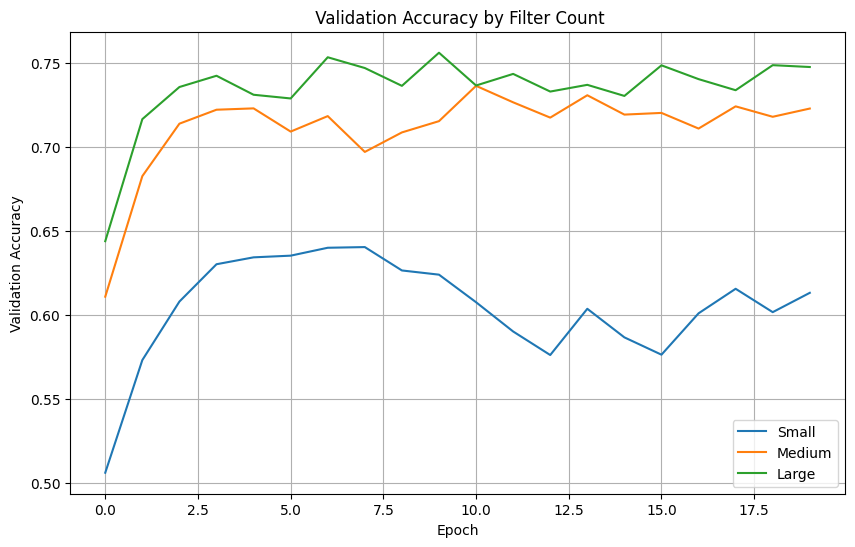

In [ ]:
#Plot: validation accuracy for all 3 filter models
plot_curves(
    filter_histories,
    list(filter_configs.keys()),
    metric='val_accuracy',
    title=' Validation Accuracy by Filter Count',
ylabel='Validation Accuracy'
)

In [ ]:
#Results Table (Task 2A)
print(f"{'Model':<10} {'Total Params':>14} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10} {'Time (s)':>10}")
print('-' * 68)
for name, res in filter_results.items():
    print(f"{name:<10} {res['params']:>14,} {res['train_acc']:>10.4f} "
          f"{res['val_acc']:>10.4f} {res['test_acc']:>10.4f} {res['time']:>10.1f}")

Model        Total Params  Train Acc    Val Acc   Test Acc   Time (s)
--------------------------------------------------------------------
Small             269,266     0.9387     0.6131     0.6058       44.1
Medium          1,116,970     0.9861     0.7227     0.7150       78.0
Large           2,360,138     0.9890     0.7474     0.7384      148.6


---
## Task 2C - Network Depth Comparison

In [ ]:
#Building three models of different depths (all use 32 filters)

def build_shallow():
    """Shallow: 4 conv layers"""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name='Shallow')
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_medium_depth():
    """Medium: 6 conv layers"""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name='Medium')
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_deep():
    """Deep: 8 conv layers"""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name='Deep')
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
#train all three depth models
depth_builders = [('Shallow', build_shallow),
                  ('Medium',  build_medium_depth),
                  ('Deep',    build_deep)]

depth_histories = []
depth_results   = {}

for name, builder in depth_builders:
    print(f"\n=== {name} ===")
    model = builder()
print('-' * 68)
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=20
    )
    depth_histories.append(history)
    depth_results[name] = {
        'params':    model.count_params(),
        'train_acc': history.history['accuracy'][-1],
        'val_acc':   history.history['val_accuracy'][-1],
        'test_acc':  test_acc,
        'time':      elapsed,
    }


=== Shallow ===
Test Acc: 0.6966 | Test Loss: 2.1302 | Time: 71.1s

=== Medium ===
Test Acc: 0.7301 | Test Loss: 0.7996 | Time: 72.1s

=== Deep ===
Test Acc: 0.7206 | Test Loss: 0.8694 | Time: 75.8s


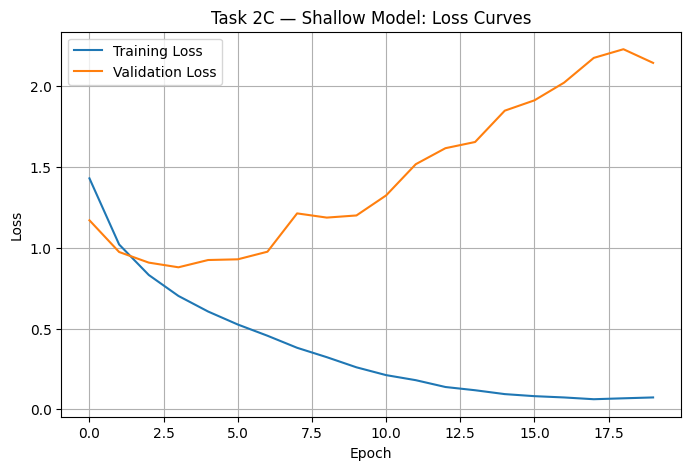

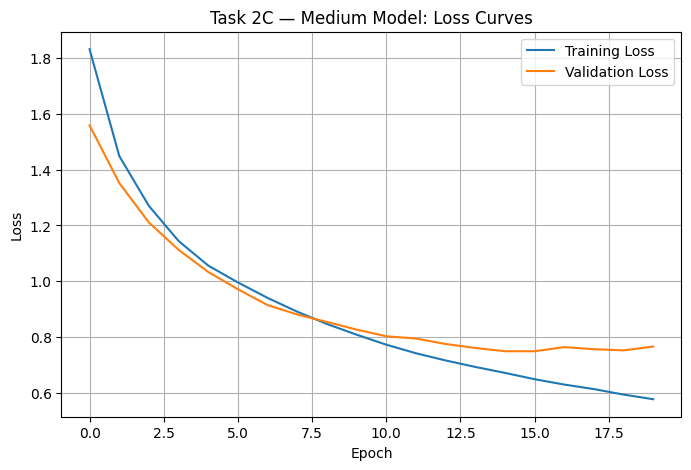

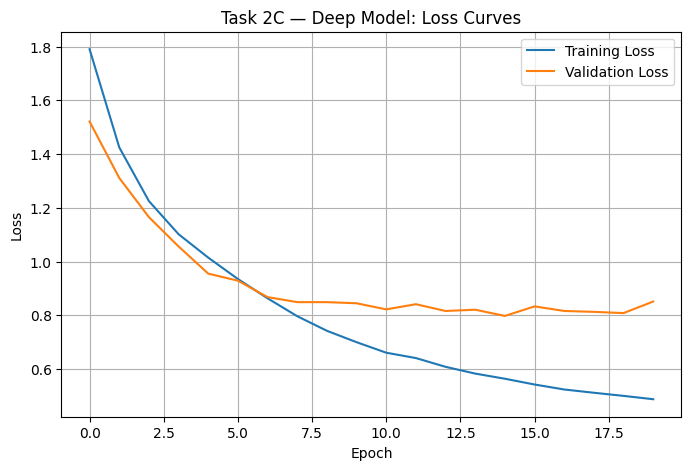

In [ ]:
##plot for "each" model
for (name, _), history in zip(depth_builders, depth_histories):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'],     label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Task 2C — {name} Model: Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:

print('-' * 68)
for name, res in depth_results.items():
    print(f"{name:<10} {res['params']:>14,} {res['train_acc']:>10.4f} "
          f"{res['val_acc']:>10.4f} {res['test_acc']:>10.4f} {res['time']:>10.1f}")

Model        Total Params  Train Acc    Val Acc   Test Acc   Time (s)
--------------------------------------------------------------------
Shallow           555,754     0.9747     0.7018     0.6966       71.1
Medium             58,154     0.7967     0.7380     0.7301       72.1
Deep               76,650     0.8269     0.7210     0.7206       75.8


In [ ]:
# Analysis: Does the deepest model perform best?whyorwhynot
print("\nAnalysis (Q15): The deepest model doesn't always perform best on CIFAR-10 (32×32 images)."
      " With small spatial resolution, aggressive pooling in 3 stages can reduce feature maps"
      " to 4×4 or smaller, losing spatial information. Deeper models may also overfit without"
      " sufficient regularization. The medium-depth model often achieves the best balance.")


Analysis (Q15): The deepest model doesn't always perform best on CIFAR-10 (32×32 images). With small spatial resolution, aggressive pooling in 3 stages can reduce feature maps to 4×4 or smaller, losing spatial information. Deeper models may also overfit without sufficient regularization. The medium-depth model often achieves the best balance.


---
# Task 3: Regularization Experiments
## Task 3A - Dropout Rate Comparison

In [4]:
#build Medium model (from 2A) with optional Dropout
# Dropout applied: after each MaxPool + before the output Dense layer.
def build_medium_with_dropout(dropout_rate=0.0, name='MediumDropout'):

    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(32, 32, 3)))
    #line1
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    #line2
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dropout_configs = [
    ('D0 (rate=0.00)', 0.00),
    ('D1 (rate=0.25)', 0.25),
    ('D2 (rate=0.50)', 0.50),
]

In [7]:
import re
import tensorflow as tf # Import tensorflow for clear_session

#train all three dropout models (30 epochs)
dropout_histories = []
dropout_results   = {}

for i, (label, rate) in enumerate(dropout_configs): # Added enumerate to get an index
    print(f"\n=== {label} ===")
    tf.keras.backend.clear_session() # Clear session for a fresh start for each model
    # Create a simple, unique name for the model using the index
    model_unique_name = f"DropoutModel_{i}"
    model = build_medium_with_dropout(rate, name=model_unique_name)
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_te, epochs=30
    )
    dropout_histories.append(history)
    train_acc_final = history.history['accuracy'][-1]
    val_acc_final   = history.history['val_accuracy'][-1]
    dropout_results[label] = {
        'train_acc':   train_acc_final,
        'val_acc':     val_acc_final,
        'test_acc':    test_acc,
        'overfit_gap': train_acc_final - val_acc_final,
    }


=== D0 (rate=0.00) ===


ValueError: 'D0_(rate=0.00)_D0_rate_0.00_conv2d_10_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

In [ ]:
ok#Plot: all 3 validation accuracy curves
plot_curves(
    dropout_histories,
    [d[0] for d in dropout_configs],
    metric='val_accuracy',
    title='Task 3A — Validation Accuracy by Dropout Rate',
    ylabel='Validation Accuracy'
)

In [ ]:
#Plot: all 3 training accuracy curves
plot_curves(
    dropout_histories,
    [d[0] for d in dropout_configs],
    metric='accuracy',
    title='Task 3A — Training Accuracy by Dropout Rate',
    ylabel='Training Accuracy'
)

In [ ]:
#Results Table (Task 3A)
print(f"{'Model':<20} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10} {'Overfit Gap':>12}")
print('-' * 66)
for label, res in dropout_results.items():
    print(f"{label:<20} {res['train_acc']:>10.4f} {res['val_acc']:>10.4f} "
          f"{res['test_acc']:>10.4f} {res['overfit_gap']:>12.4f}")

#Best test accuracy and smallest overfit gap
best_test  = min(dropout_results, key=lambda k: -dropout_results[k]['test_acc'])
best_gap   = min(dropout_results, key=lambda k:  dropout_results[k]['overfit_gap'])
print(f"\nBest test accuracy: {best_test}")
print(f"Smallest overfit gap: {best_gap}")

---
 Task 3B - Early Stopping Comparison

In [ ]:


es_configs = [
    ('ES0 (no ES)',   50, None),
    ('ES2 (pat=5)',   50, callbacks.EarlyStopping(monitor='val_loss', patience=5,  restore_best_weights=True)),
    ('ES3 (pat=10)',  50, callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)),
]

es_histories = []
es_results   = {}

for label, epochs, es_cb in es_configs:
    print(f"\n=== {label} ===")
    cb_list = [es_cb] if es_cb else []
    model   = build_medium_with_dropout(0.0, name=label.replace(' ', '_'))
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
        epochs=epochs, extra_callbacks=cb_list
    )
    es_histories.append(history)
    stopped_at    = len(history.history['val_loss'])
    best_val_loss = min(history.history['val_loss'])
    es_results[label] = {
        'stopped_at':    stopped_at,
        'best_val_loss': best_val_loss,
        'test_acc':      test_acc,
        'time':          elapsed,
    }
    print(f"Stopped at epoch {stopped_at}, best val_loss={best_val_loss:.4f}")

In [ ]:
#Plot: val loss for ES0, ES2, ES3 with vertical stopping-point markers
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['steelblue', 'darkorange', 'green']

for (label, _, _), history, color in zip(es_configs, es_histories, colors):
    epochs_run = es_results[label]['stopped_at']
    ax.plot(history.history['val_loss'], label=label, color=color)
    #mark where it sttops with a dash line
    if 'pat' in label:
        ax.axvline(x=epochs_run - 1, linestyle='--', color=color, alpha=0.7,
                   label=f'{label} stopped @ ep {epochs_run}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Task 3B — Validation Loss with Early Stopping')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Results Table (Task 3B)
print(f"{'Experiment':<18} {'Stopped@Ep':>11} {'Best Val Loss':>14} {'Test Acc':>10} {'Time (s)':>10}")
print('-' * 67)
for label, res in es_results.items():
    print(f"{label:<18} {res['stopped_at']:>11} {res['best_val_loss']:>14.4f} "
          f"{res['test_acc']:>10.4f} {res['time']:>10.1f}")

In [ ]:
#analysis: patience=5 vs patience=10
ep_es2 = es_results['ES2 (pat=5)']['stopped_at']
ep_es3 = es_results['ES3 (pat=10)']['stopped_at']
acc_es0 = es_results['ES0 (no ES)']['test_acc']
acc_es2 = es_results['ES2 (pat=5)']['test_acc']
acc_es3 = es_results['ES3 (pat=10)']['test_acc']

print(f"ES2 stopped at epoch {ep_es2} → test acc {acc_es2:.4f}")
print(f"ES3 stopped at epoch {ep_es3} → test acc {acc_es3:.4f}")
print(f"ES0 (no stop, 50ep)  → test acc {acc_es0:.4f}")
print("""
Interpretation:
- patience=5 (ES2) can be too aggressive if val_loss has short noisy plateaus;
  it may stop before the model finds a deeper minimum, sacrificing test accuracy.
- patience=10 (ES3) gives the model more time to recover from transient
  fluctuations, striking a better balance between training time and generalisation.
- If ES3 stops well before epoch 50 yet matches ES0 in test accuracy, it confirms
  that further training offers no benefit - patience=10 is appropriately lenient.
- The best configuration depends on the results: compare test accuracy and epochs
  saved vs ES0 to draw the final conclusion.
""")

## task 4-A

In [ ]:
model = build_filter_model(*filter_configs["Medium"])
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}
#we try the model with each optimizer and record the results
opt_histories = []
opt_results = {}
for name, opt in optimizers.items():
    print(f"\n=== {name} ===")
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=30, batch_size=128
    )
    opt_histories.append(history)
    opt_results[name] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'time': elapsed,
    }


=== SGD ===
Test Acc: 0.5236 | Test Loss: 1.3531 | Time: 121.8s

=== Momentum ===
Test Acc: 0.6434 | Test Loss: 1.5294 | Time: 113.2s

=== AdaGrad ===
Test Acc: 0.6857 | Test Loss: 1.9170 | Time: 113.1s

=== RMSProp ===
Test Acc: 0.7083 | Test Loss: 3.7976 | Time: 112.3s

=== Adam ===
Test Acc: 0.7102 | Test Loss: 3.0271 | Time: 113.7s


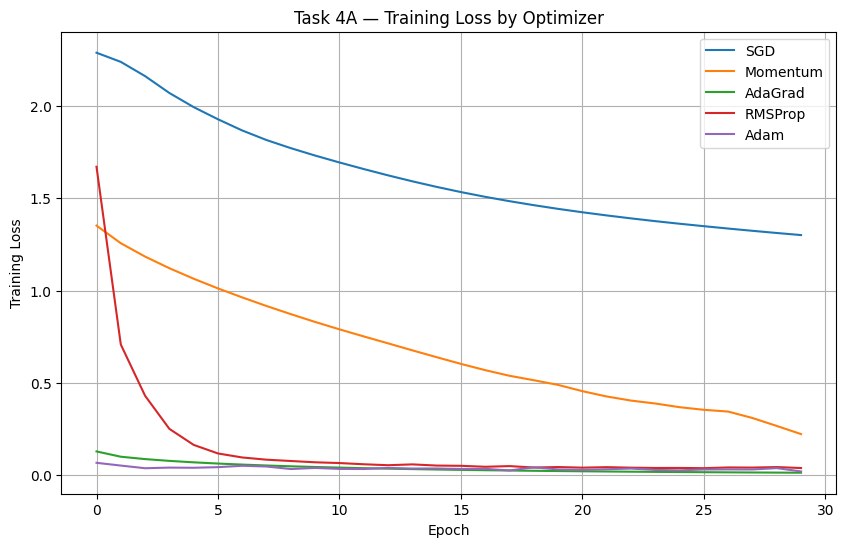

In [ ]:
#Plot: all 5 training loss curves on one graph
plt.figure(figsize=(10, 6))
for history, name in zip(opt_histories, optimizers.keys()):
    plt.plot(history.history['loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Task 4A — Training Loss by Optimizer')
plt.legend()
plt.grid(True)
plt.show()

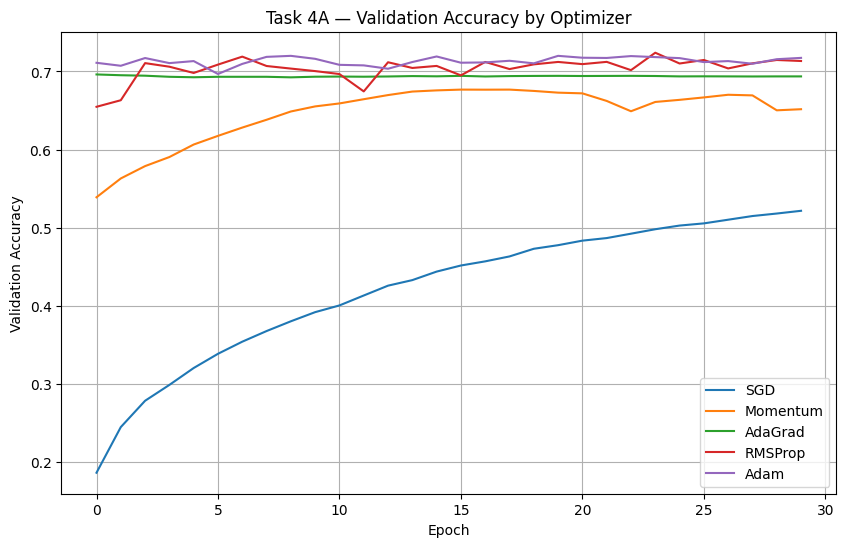

In [ ]:
#Plot all 5 validation accuracy curves on one graph
plt.figure(figsize=(10, 6))
for history, name in zip(opt_histories, optimizers.keys()):
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Task 4A — Validation Accuracy by Optimizer')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#which optimizer converges fastest?
for name, res in opt_results.items():
    print(f"{name:<10} → Train Acc: {res['train_acc']:.4f} | Val Acc: {res['val_acc']:.4f} | Test Acc: {res['test_acc']:.4f} | Time: {res['time']:.1f}s")

SGD        → Train Acc: 0.5417 | Val Acc: 0.5217 | Test Acc: 0.5236 | Time: 121.8s
Momentum   → Train Acc: 0.9268 | Val Acc: 0.6517 | Test Acc: 0.6434 | Time: 113.2s
AdaGrad    → Train Acc: 0.9998 | Val Acc: 0.6937 | Test Acc: 0.6857 | Time: 113.1s
RMSProp    → Train Acc: 0.9908 | Val Acc: 0.7134 | Test Acc: 0.7083 | Time: 112.3s
Adam       → Train Acc: 0.9934 | Val Acc: 0.7174 | Test Acc: 0.7102 | Time: 113.7s


In [ ]:
#Using the Adam optimizer, train with 3 different learning rates (30 epochs, batch_size=128): 0.01, 0.001, 0.0001
#we print train loss, validation loss and test loss for each learning rate
lr_values = [0.01, 0.001, 0.0001]
lr_histories = []
lr_results = {}
for lr in lr_values:
    print(f"\n=== Adam with LR={lr} ===")
    model = build_filter_model(*filter_configs["Medium"])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=30, batch_size=128
    )
    lr_histories.append(history)
    lr_results[lr] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'time': elapsed,
    }


=== Adam with LR=0.01 ===
Test Acc: 0.4739 | Test Loss: 2.0338 | Time: 111.7s

=== Adam with LR=0.001 ===
Test Acc: 0.7126 | Test Loss: 2.5241 | Time: 116.0s

=== Adam with LR=0.0001 ===
Test Acc: 0.6652 | Test Loss: 1.3232 | Time: 116.6s



=== Training Final Model ===
Test Acc: 0.7627 | Test Loss: 0.6735 | Time: 177.4s

Final Model - Test Acc: 0.7627 | Test Loss: 0.6735 | Time: 177.4s
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


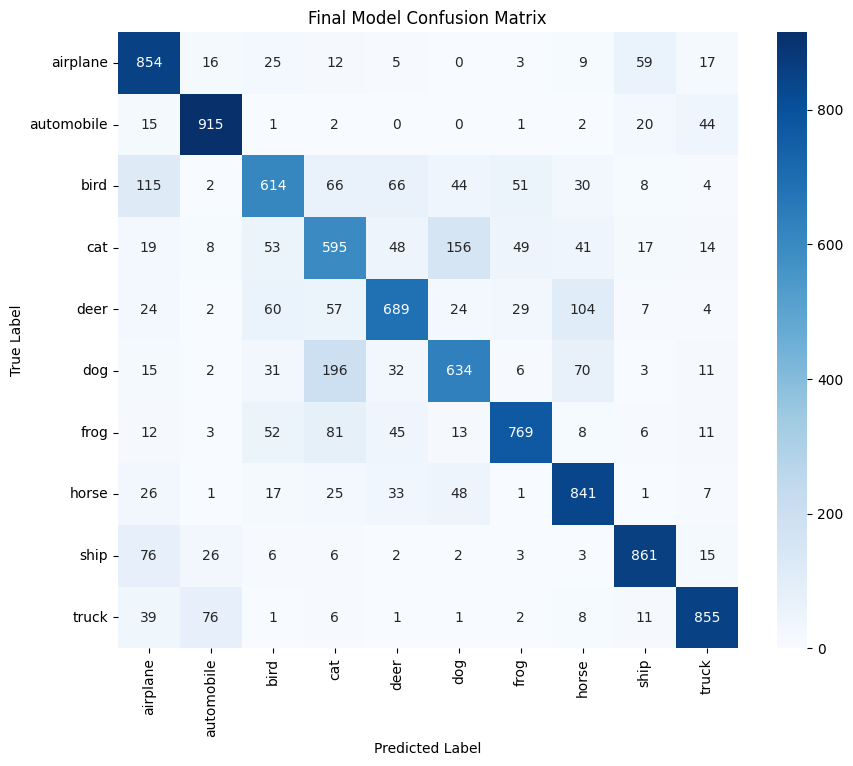

In [8]:
# Final Model Configuration

def build_final_model(dropout_rate=0.25, learning_rate=0.001, name='FinalModel'):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout_rate),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout_rate),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(), # As in build_medium_depth
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Configure ImageDataGenerator for augmentation (using parameters from Task 1B)
datagen_final = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
# Fit on training data to compute any internal statistics (e.g., for feature-wise normalization if used)
datagen_final.fit(x_train_std)


# Define Early Stopping callback
early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

# Train the final model
print("\n=== Training Final Model ===")
tf.keras.backend.clear_session() # Clear session before building the final model
final_model = build_final_model(dropout_rate=0.25, learning_rate=0.001)

# Prepare data generators for training with augmentation
aug_gen_final = datagen_final.flow(x_train_std, to_categorical(y_train, 10), batch_size=128)
val_data_final   = (x_val_std, to_categorical(y_val, 10))

history_final, test_acc_final, test_loss_final, elapsed_final = train_and_evaluate(
    model=final_model,
    x_tr=x_train_std, # Not directly used for fitting aug_gen_final but kept for train_and_evaluate signature
    y_tr=y_train,     # Not directly used for fitting aug_gen_final but kept for train_and_evaluate signature
    x_v=x_val_std,
    y_v=y_val,
    x_te=x_test_std,
    y_te=y_test,
    epochs=50,
    batch_size=128,
    extra_callbacks=[early_stopping_cb]
)

print(f"\nFinal Model - Test Acc: {test_acc_final:.4f} | Test Loss: {test_loss_final:.4f} | Time: {elapsed_final:.1f}s")

# Generate predictions for the confusion matrix
y_pred_final = final_model.predict(x_test_std)
y_pred_classes_final = np.argmax(y_pred_final, axis=1)
y_true_classes_final = y_test.flatten()

# Calculate confusion matrix
cm_final = confusion_matrix(y_true_classes_final, y_pred_classes_final)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Model Confusion Matrix')
plt.show()



--- Detailed Performance Analysis ---

Top 3 Worst-Performing Classes (Lowest Recall):
- cat: 0.5950
- bird: 0.6140
- dog: 0.6340

--- Misclassified Images for Worst-Performing Classes ---


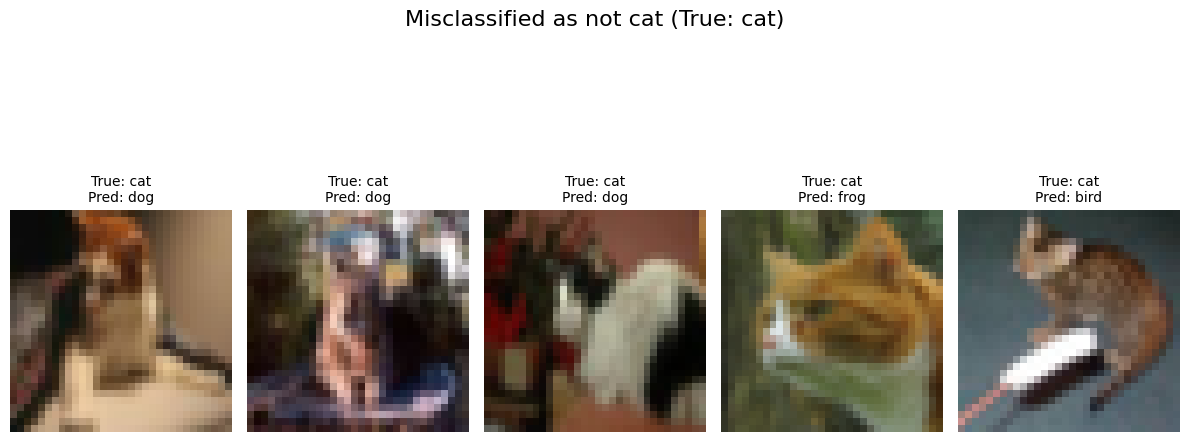

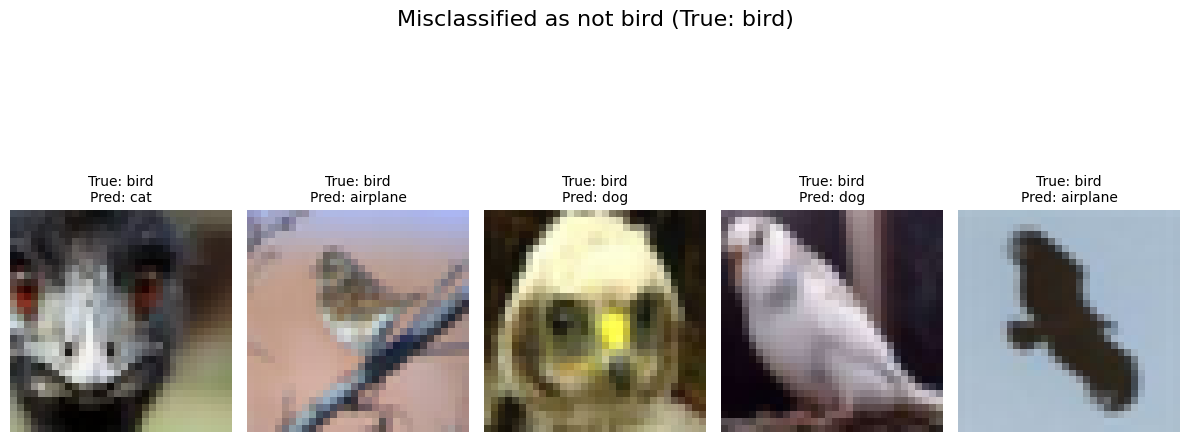

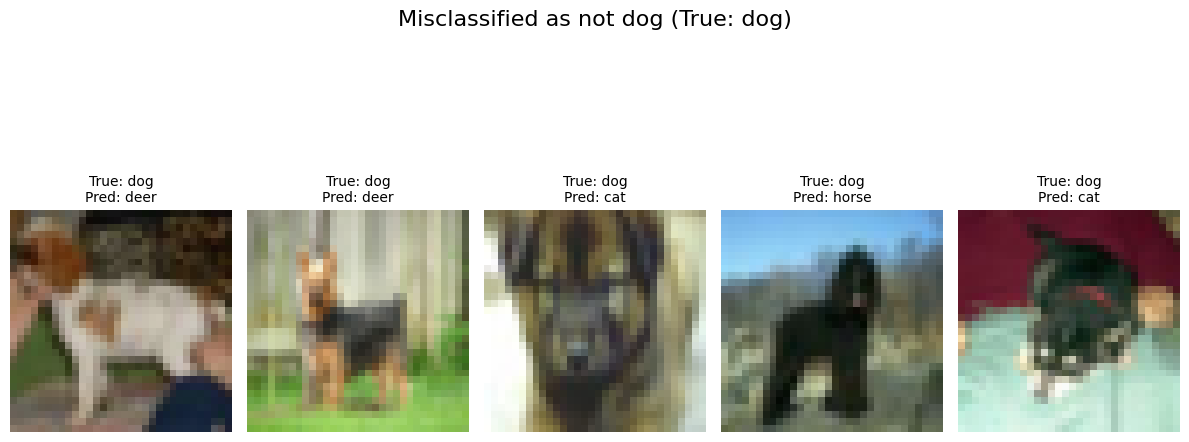


--- Top 3 Most Confused Class Pairs ---
- cat <-> dog: Total Confusions = 352 (True cat as dog: 156, True dog as cat: 196)


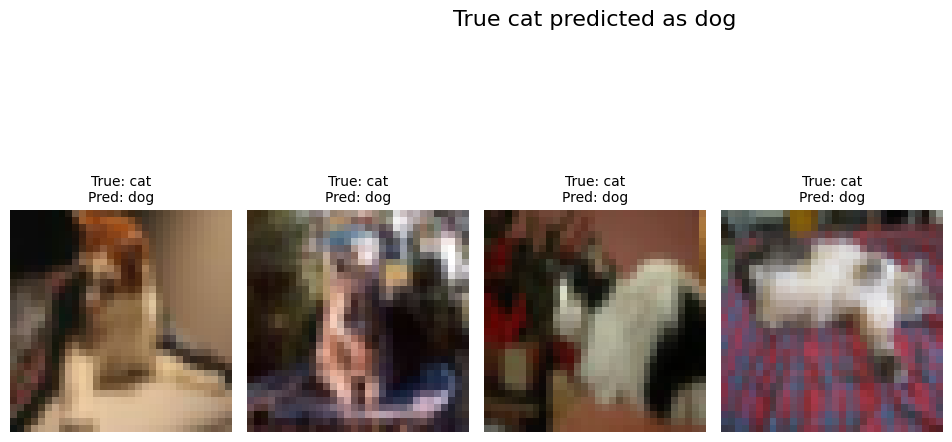

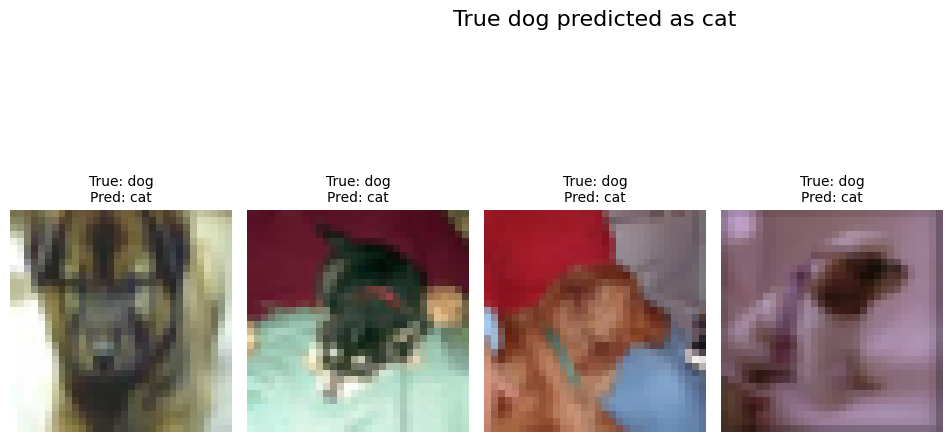

- airplane <-> bird: Total Confusions = 140 (True airplane as bird: 25, True bird as airplane: 115)


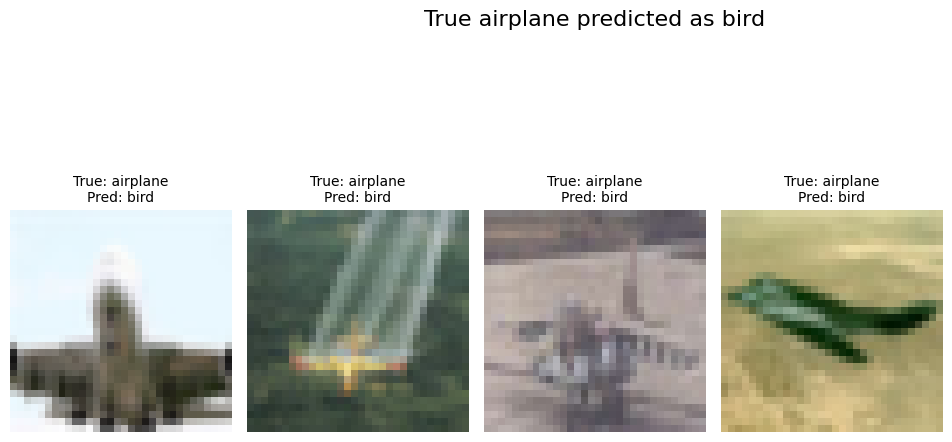

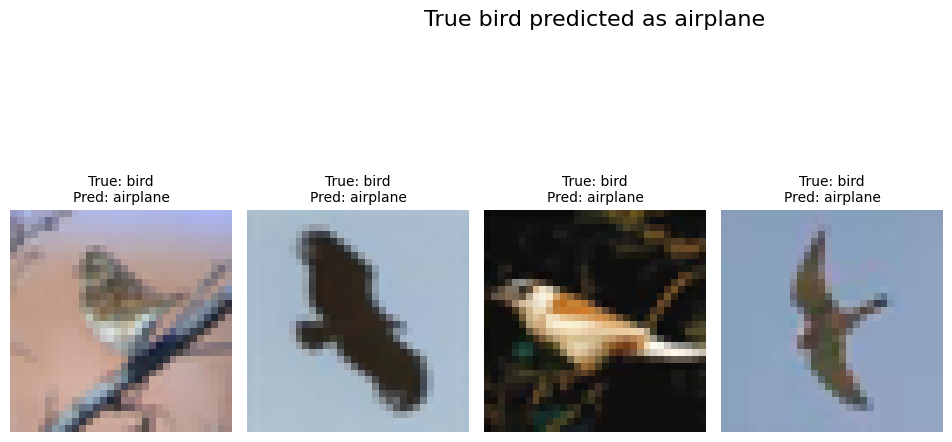

- deer <-> horse: Total Confusions = 137 (True deer as horse: 104, True horse as deer: 33)


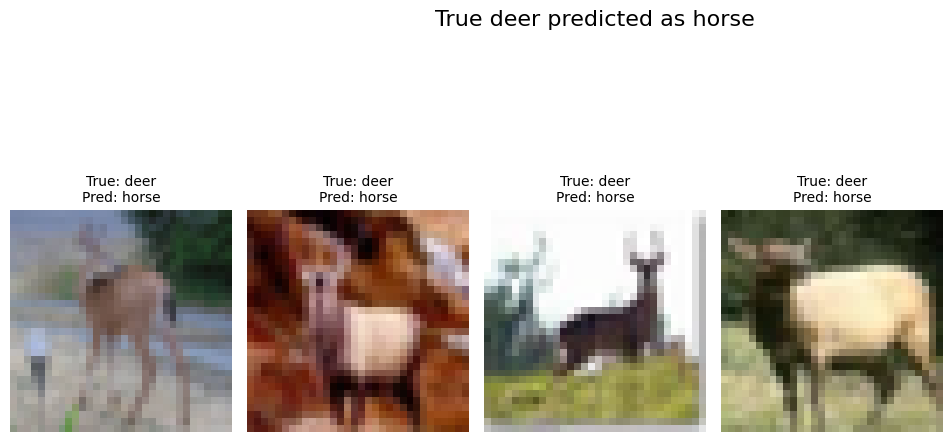

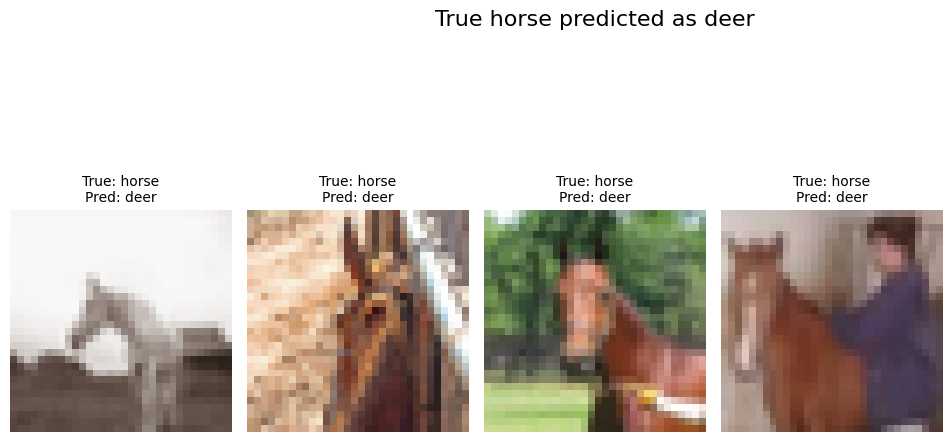

In [9]:
print("\n--- Detailed Performance Analysis ---\n")

# Helper function to display images
def display_misclassified_images(indices, true_labels, pred_labels, images, title="Misclassified Images"):
    plt.figure(figsize=(12, 6))
    plt.suptitle(title, fontsize=16)
    for i, idx in enumerate(indices):
        if i >= 5: break # Display up to 5 images
        plt.subplot(1, 5, i + 1)
        # Clip image data to [0, 255] and convert to uint8 for display
        img_to_display = np.clip(images[idx], 0, 255).astype('uint8')
        plt.imshow(img_to_display)
        true_class_name = CLASS_NAMES[true_labels[idx]]
        pred_class_name = CLASS_NAMES[pred_labels[idx]]
        plt.title(f"True: {true_class_name}\nPred: {pred_class_name}", fontsize=10)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 1. Find the 3 worst-performing classes (lowest recall)

# Calculate per-class recall
recall_per_class = []
for i in range(10):
    true_positives = cm_final[i, i]
    false_negatives = np.sum(cm_final[i, :]) - true_positives
    # Handle division by zero for classes not present in test set (unlikely for CIFAR-10)
    if (true_positives + false_negatives) > 0:
        recall = true_positives / (true_positives + false_negatives)
    else:
        recall = 0.0 # Or NaN, depending on desired behavior
    recall_per_class.append((CLASS_NAMES[i], recall))

# Sort by recall and get the 3 worst
worst_performing_classes = sorted(recall_per_class, key=lambda x: x[1])[:3]
print("Top 3 Worst-Performing Classes (Lowest Recall):")
for class_name, recall_val in worst_performing_classes:
    print(f"- {class_name}: {recall_val:.4f}")
x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized
 = tf.image.resize(x_val_standardized,
 (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_standardized, (48, 48)).numpy()
# 2. For each of those 3 classes, display 5 misclassified images
print("\n--- Misclassified Images for Worst-Performing Classes ---")
for class_name, _ in worst_performing_classes:
    class_idx = CLASS_NAMES.index(class_name)
    misclassified_indices = []
    for i in range(len(y_test)):
        if y_true_classes_final[i] == class_idx and y_pred_classes_final[i] != class_idx:
            misclassified_indices.append(i)
        if len(misclassified_indices) >= 5: # Limit to 5 images per class
            break
    if misclassified_indices:
        display_misclassified_images(
            misclassified_indices, y_true_classes_final, y_pred_classes_final, x_test,
            title=f"Misclassified as not {class_name} (True: {class_name})"
        )
    else:
        print(f"No misclassified images found for {class_name}.")

# 3. Find the top 3 most confused class pairs (e.g., cat<->dog). Display 4 examples from each confusion direction.

# Create a list of confusion counts for off-diagonal elements
confusion_pairs = []
for i in range(10):
    for j in range(i + 1, 10): # Only consider upper triangle to avoid duplicates (A,B) vs (B,A)
        # Sum of A predicted as B and B predicted as A
        total_confusion = cm_final[i, j] + cm_final[j, i]
        if total_confusion > 0:
            confusion_pairs.append({
                'class1_idx': i,
                'class2_idx': j,
                'count_c1_as_c2': cm_final[i, j],
                'count_c2_as_c1': cm_final[j, i],
                'total_confusion': total_confusion

            })

# Sort by total confusion and get the top 3
top_confused_pairs = sorted(confusion_pairs, key=lambda x: x['total_confusion'], reverse=True)[:3]

print("\n--- Top 3 Most Confused Class Pairs ---")
for pair_info in top_confused_pairs:
    c1_idx = pair_info['class1_idx']
    c2_idx = pair_info['class2_idx']
    c1_name = CLASS_NAMES[c1_idx]
    c2_name = CLASS_NAMES[c2_idx]
    print(f"- {c1_name} <-> {c2_name}: Total Confusions = {pair_info['total_confusion']} "
          f"(True {c1_name} as {c2_name}: {pair_info['count_c1_as_c2']}, "
          f"True {c2_name} as {c1_name}: {pair_info['count_c2_as_c1']})")

    # Display images for c1 predicted as c2
    c1_as_c2_indices = []
    for i in range(len(y_test)):
        if y_true_classes_final[i] == c1_idx and y_pred_classes_final[i] == c2_idx:
            c1_as_c2_indices.append(i)
        if len(c1_as_c2_indices) >= 4: # Limit to 4 images
            break
    if c1_as_c2_indices:
        display_misclassified_images(
            c1_as_c2_indices, y_true_classes_final, y_pred_classes_final, x_test,
            title=f"True {c1_name} predicted as {c2_name}"
        )

    # Display images for c2 predicted as c1
    c2_as_c1_indices = []
    for i in range(len(y_test)):
        if y_true_classes_final[i] == c2_idx and y_pred_classes_final[i] == c1_idx:
            c2_as_c1_indices.append(i)
        if len(c2_as_c1_indices) >= 4: # Limit to 4 images
            break
    if c2_as_c1_indices:
        display_misclassified_images(
            c2_as_c1_indices, y_true_classes_final, y_pred_classes_final, x_test,
            title=f"True {c2_name} predicted as {c1_name}"
        )



## Task 6

In [11]:
x_train_resized = tf.image.resize(x_train_std, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_std,(48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_std, (48, 48)).numpy()


=== Training Medium CNN (48x48 input) ===
Test Acc: 0.6843 | Test Loss: 2.9442 | Time: 154.6s

Medium CNN (48x48) - Test Acc: 0.6843 | Test Loss: 2.9442 | Time: 154.6s


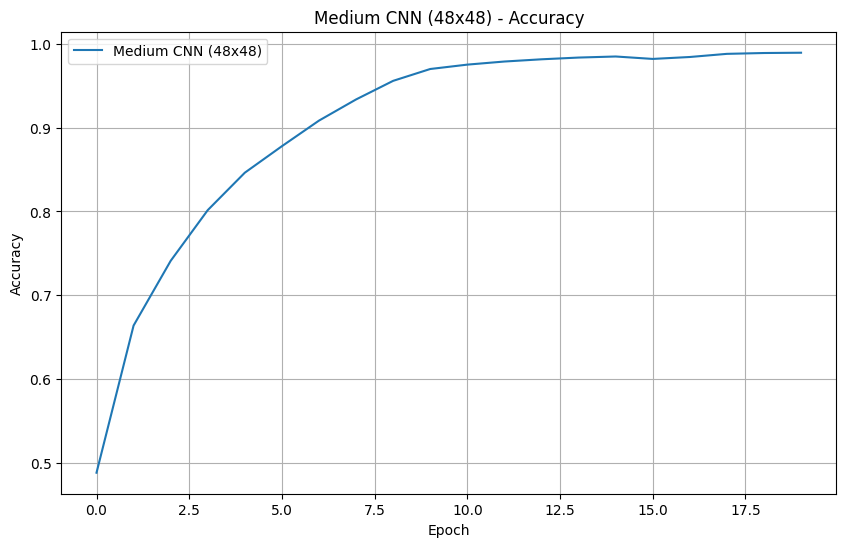

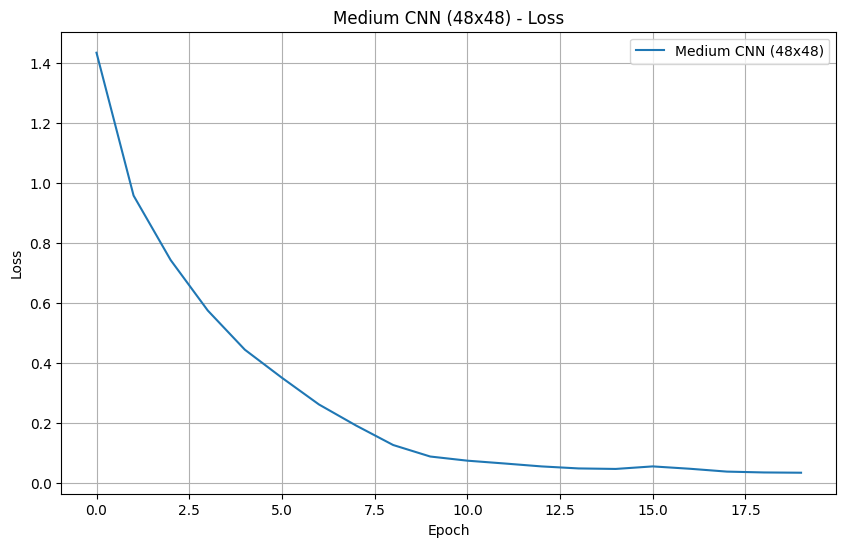

In [13]:
def build_medium_cnn_48x48(input_shape=(48, 48, 3), name='MediumCNN_48x48'):
    """Medium filter model with 48x48 input shape."""
    # Reusing the build_filter_model structure
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Block 1 - Medium filters (32, 32)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # Block 2 - Medium filters (64, 64)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ], name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("\n=== Training Medium CNN (48x48 input) ===")
tf.keras.backend.clear_session() # Clear session for a fresh start
model_medium_48 = build_medium_cnn_48x48()
history_medium_48, test_acc_medium_48, test_loss_medium_48, elapsed_medium_48 = train_and_evaluate(
    model=model_medium_48,
    x_tr=x_train_resized,
    y_tr=y_train,
    x_v=x_val_resized,
    y_v=y_val,
    x_te=x_test_resized,
    y_te=y_test,
    epochs=20,
    batch_size=128
)

print(f"\nMedium CNN (48x48) - Test Acc: {test_acc_medium_48:.4f} | Test Loss: {test_loss_medium_48:.4f} | Time: {elapsed_medium_48:.1f}s")

# Plotting training/validation curves for this model
plot_curves(
    [history_medium_48],
    ['Medium CNN (48x48)'],
    metric='accuracy',
    title='Medium CNN (48x48) - Accuracy',
    ylabel='Accuracy'
)
plot_curves(
    [history_medium_48],
    ['Medium CNN (48x48)'],
    metric='loss',
    title='Medium CNN (48x48) - Loss',
    ylabel='Loss'
)

Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


=== Training VGG16 Transfer Learning Model ===
Test Acc: 0.6895 | Test Loss: 0.9117 | Time: 370.4s

Final VGG16 Model - Test Acc: 0.6895 | Test Loss: 0.9117 | Time: 370.4s


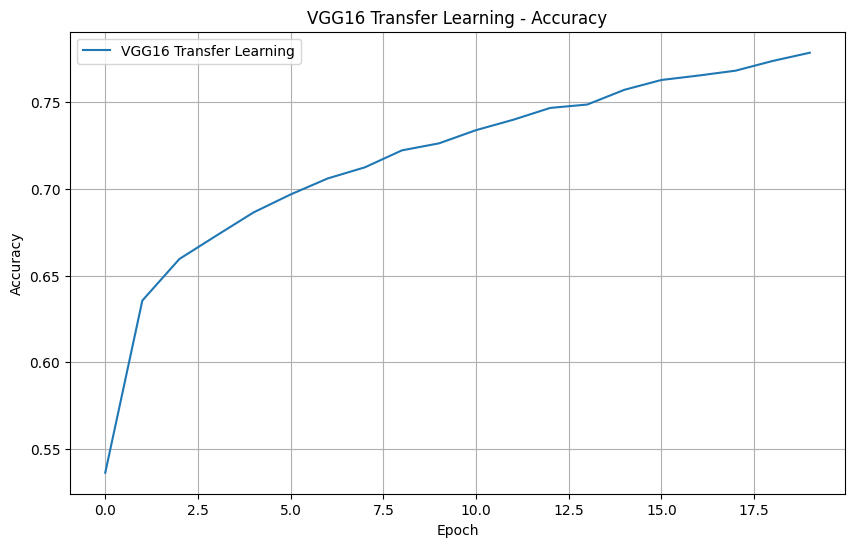

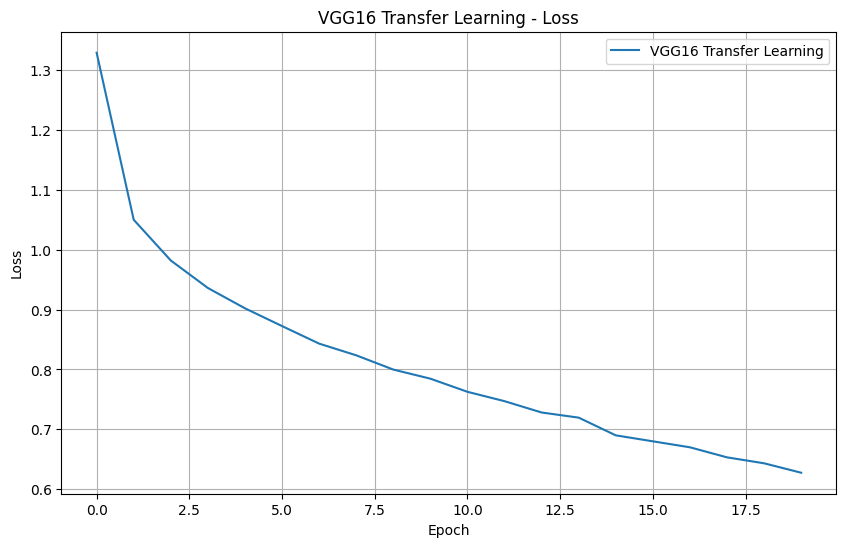

In [14]:
from tensorflow.keras.applications import VGG16

# 1. Load pre-trained VGG16 model
# Input shape matches CIFAR-10 (48, 48, 3)
# include_top=False removes the classification layers
tf.keras.backend.clear_session() # Clear session to avoid naming conflicts
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3) # Resized image size
)

# 2. Freeze all layers of the VGG16 base
for layer in vgg_base.layers:
    layer.trainable = False

# 3. Add your own classification head on top
model_vgg = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='VGG16_TransferLearning')

# 4. Compile the model
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

# 5. Train the model for 20 epochs, batch_size=128
print("\n=== Training VGG16 Transfer Learning Model ===")
history_vgg, test_acc_vgg, test_loss_vgg, elapsed_vgg = train_and_evaluate(
    model=model_vgg,
    x_tr=x_train_resized, # Using resized data
    y_tr=y_train,
    x_v=x_val_resized,
    y_v=y_val,
    x_te=x_test_resized,
    y_te=y_test,
    epochs=20,
    batch_size=128
)

print(f"\nFinal VGG16 Model - Test Acc: {test_acc_vgg:.4f} | Test Loss: {test_loss_vgg:.4f} | Time: {elapsed_vgg:.1f}s")

# Plotting training/validation curves for VGG16 model
plot_curves(
    [history_vgg],
    ['VGG16 Transfer Learning'],
    metric='accuracy',
    title='VGG16 Transfer Learning - Accuracy',
    ylabel='Accuracy'
)
plot_curves(
    [history_vgg],
    ['VGG16 Transfer Learning'],
    metric='loss',
    title='VGG16 Transfer Learning - Loss',
    ylabel='Loss'
)

Model: "VGG16_FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


=== Training VGG16 Fine-Tuning Model ===
Test Acc: 0.8228 | Test Loss: 0.5539 | Time: 449.5s

Final VGG16 Fine-Tuning Model - Test Acc: 0.8228 | Test Loss: 0.5539 | Time: 449.5s


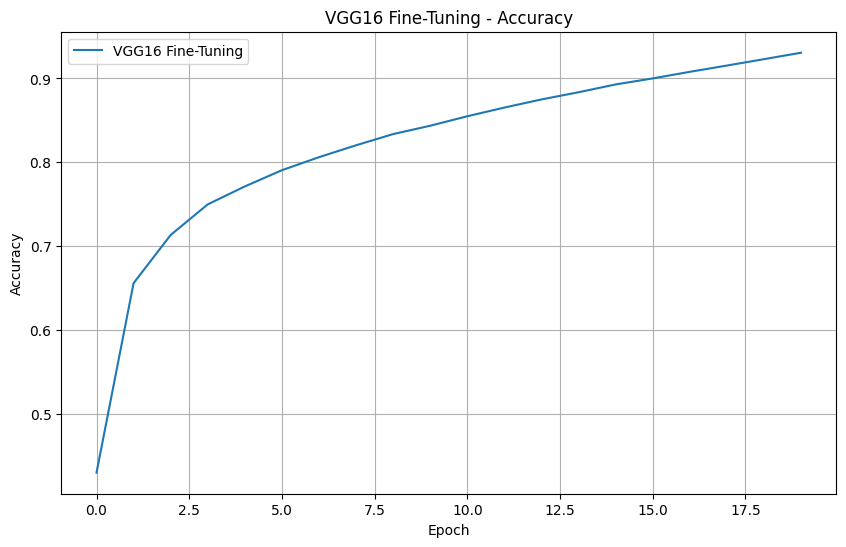

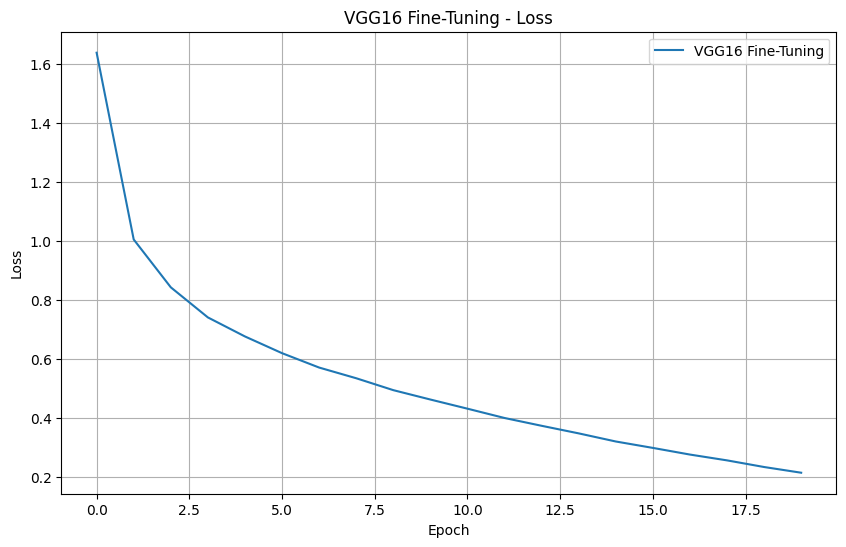

In [15]:
from tensorflow.keras.applications import VGG16

# 1. Load pre-trained VGG16 model
# Input shape matches CIFAR-10 (48, 48, 3)
# include_top=False removes the classification layers
tf.keras.backend.clear_session() # Clear session to avoid naming conflicts
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3) # Resized image size
)

# 2. Freeze all layers of the VGG16 base initially
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze the last 4 layers of the VGG16 base
num_vgg_layers = len(vgg_base.layers)
for layer in vgg_base.layers[num_vgg_layers - 4:]: # Unfreeze the last 4 layers
    layer.trainable = True

# 3. Add your own classification head on top
model_vgg_finetune = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='VGG16_FineTuning')

# 4. Compile the model with a lower learning rate
model_vgg_finetune.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg_finetune.summary()

# 5. Train the model for 20 epochs, batch_size=128
print("\n=== Training VGG16 Fine-Tuning Model ===")
history_vgg_finetune, test_acc_vgg_finetune, test_loss_vgg_finetune, elapsed_vgg_finetune = train_and_evaluate(
    model=model_vgg_finetune,
    x_tr=x_train_resized, # Using resized data
    y_tr=y_train,
    x_v=x_val_resized,
    y_v=y_val,
    x_te=x_test_resized,
    y_te=y_test,
    epochs=20,
    batch_size=128
)

print(f"\nFinal VGG16 Fine-Tuning Model - Test Acc: {test_acc_vgg_finetune:.4f} | Test Loss: {test_loss_vgg_finetune:.4f} | Time: {elapsed_vgg_finetune:.1f}s")

# Plotting training/validation curves for VGG16 fine-tuning model
plot_curves(
    [history_vgg_finetune],
    ['VGG16 Fine-Tuning'],
    metric='accuracy',
    title='VGG16 Fine-Tuning - Accuracy',
    ylabel='Accuracy'
)
plot_curves(
    [history_vgg_finetune],
    ['VGG16 Fine-Tuning'],
    metric='loss',
    title='VGG16 Fine-Tuning - Loss',
    ylabel='Loss'
)